In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sentence_transformers import SentenceTransformer

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "dualtest_experiments" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "DUALTEST"))

print(PROJECT_ROOT)

from reference_model import ReferenceModel
from metrics import edit_similarity, run_length


c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final


In [26]:
csv_path = PROJECT_ROOT / "results" / "booktection_llama33_70b_pythia410m_n1000_checkpoint.csv"

df = pd.read_csv(csv_path)
df = df[df["target_completion"].notna()].copy()

len(df), df.head()

(1000,
                         id      dataset  label  membership  \
 0  booktection_06344_A.txt  booktection      1      member   
 1  booktection_13775_A.txt  booktection      0  non_member   
 2  booktection_15728_A.txt  booktection      0  non_member   
 3  booktection_09652_A.txt  booktection      1      member   
 4  booktection_15876_A.txt  booktection      0  non_member   
 
                                               prefix  \
 0  Valancourt, who heard these calls, and also th...   
 1  She pulled her leg back out of the window and ...   
 2  But shed kept the secret to herself. What had ...   
 3  They descended the staircase together,--gaunt,...   
 4  The light refracted from each triangle was an ...   
 
                                         ground_truth  \
 0  assured her, in a voice that trembled, but not...   
 1  speak. It was back in the sixties, so, you kno...   
 2  thought, shed barely found out herself and the...   
 3  The eye of their Father seemed to be 

In [27]:
reference = ReferenceModel(
    model_name="EleutherAI/pythia-410m",
    device="cpu",
)

Loading weights: 100%|██████████| 292/292 [00:01<00:00, 224.63it/s]


In [28]:
@torch.no_grad()
def reference_complete(reference, prefix_text, max_new_tokens=64):
    ids = reference.tokenizer(
        prefix_text,
        return_tensors="pt",
    ).input_ids.to(reference.device)

    out = reference.model.generate(
        ids,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=reference.tokenizer.eos_token_id,
    )

    new_ids = out[0, ids.shape[1]:].tolist()
    text = reference.tokenizer.decode(new_ids, skip_special_tokens=True)

    return text, new_ids

In [29]:
out_path = PROJECT_ROOT / "results" / "booktection_reference_vs_target_llama33_70b.csv"

if out_path.exists():
    df_out = pd.read_csv(out_path)
    done_ids = set(df_out["id"].astype(str))
    rows = df_out.to_dict("records")
    print("Retomando:", len(done_ids))
else:
    done_ids = set()
    rows = []

for i, row in df.iterrows():
    row_id = str(row["id"])

    if row_id in done_ids:
        continue

    ref_text, ref_tokens = reference_complete(
        reference,
        row["prefix"],
        max_new_tokens=64,
    )

    rows.append({
        **row.to_dict(),
        "reference_completion": ref_text,
    })

    done_ids.add(row_id)

    if len(rows) % 20 == 0:
        pd.DataFrame(rows).to_csv(out_path, index=False)
        print("Guardados:", len(rows))

pd.DataFrame(rows).to_csv(out_path, index=False)

df_cmp = pd.DataFrame(rows)
df_cmp.head()

Guardados: 20
Guardados: 40
Guardados: 60
Guardados: 80
Guardados: 100
Guardados: 120
Guardados: 140
Guardados: 160
Guardados: 180
Guardados: 200
Guardados: 220
Guardados: 240
Guardados: 260
Guardados: 280
Guardados: 300
Guardados: 320
Guardados: 340
Guardados: 360
Guardados: 380
Guardados: 400
Guardados: 420
Guardados: 440
Guardados: 460
Guardados: 480
Guardados: 500
Guardados: 520
Guardados: 540
Guardados: 560
Guardados: 580
Guardados: 600
Guardados: 620
Guardados: 640
Guardados: 660
Guardados: 680
Guardados: 700
Guardados: 720
Guardados: 740
Guardados: 760
Guardados: 780
Guardados: 800
Guardados: 820
Guardados: 840
Guardados: 860
Guardados: 880
Guardados: 900
Guardados: 920
Guardados: 940
Guardados: 960
Guardados: 980
Guardados: 1000


,id,dataset,label,membership,prefix,ground_truth,target_completion,run_length,p_rlb,edit_similarity,p_esb,log_p_esb,target_model,reference_model,reference_completion
0,booktection_06344_A.txt,booktection,1,member,"Valancourt, who heard these calls, and also th...","assured her, in a voice that trembled, but not...",felt a deep pang of self-reproach for having o...,0,1.000000e+00,0.248485,0.0,-171.504977,llama-3.3-70b-versatile,EleutherAI/pythia-410m,"hastened to her assistance.\n\n""I am very muc..."
1,booktection_13775_A.txt,booktection,0,non_member,She pulled her leg back out of the window and ...,"speak. It was back in the sixties, so, you kno...","speak, fearing that the words that would come ...",2,3.002872e-08,0.259366,0.0,-185.058010,llama-3.3-70b-versatile,EleutherAI/pythia-410m,"say anything.\n\n""I think you should go back ..."
2,booktection_15728_A.txt,booktection,0,non_member,But shed kept the secret to herself. What had ...,"thought, shed barely found out herself and the...","had only just found out herself, and the news ...",0,1.000000e+00,0.325714,0.0,-154.535264,llama-3.3-70b-versatile,EleutherAI/pythia-410m,"had been a little too young to be pregnant, b..."
3,booktection_09652_A.txt,booktection,1,member,"They descended the staircase together,--gaunt,...",The eye of their Father seemed to be withdrawn...,"The warm sunlight, which had been streaming do...",1,2.850067e-05,0.273481,0.0,-157.009243,llama-3.3-70b-versatile,EleutherAI/pythia-410m,"\n\n""I am the Lord's, and I am the God of Jaco..."
4,booktection_15876_A.txt,booktection,0,non_member,The light refracted from each triangle was an ...,that originates from Omal is the audacity. Muq...,that remained untouched was the ancient temple...,1,1.054699e-05,0.270195,0.0,-179.861253,llama-3.3-70b-versatile,EleutherAI/pythia-410m,of the palace that was not Omal was the court...


In [39]:
df_cmp["edit_similarity_target"] = df_cmp.apply(
    lambda r: edit_similarity(
        str(r["target_completion"]),
        str(r["ground_truth"]),
    ),
    axis=1,
)

df_cmp["edit_similarity_reference"] = df_cmp.apply(
    lambda r: edit_similarity(
        str(r["reference_completion"]),
        str(r["ground_truth"]),
    ),
    axis=1,
)

df_cmp["delta_edit_similarity"] = (
    df_cmp["edit_similarity_target"]
    - df_cmp["edit_similarity_reference"]
)

df_cmp.groupby("label")[[
    "edit_similarity_target",
    "edit_similarity_reference",
    "delta_edit_similarity",
]].mean()

,edit_similarity_target,edit_similarity_reference,delta_edit_similarity
label,,,
0,0.255718,0.253229,0.002489
1,0.266035,0.259449,0.006586


In [40]:
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

gt = df_cmp["ground_truth"].fillna("").astype(str).tolist()
target_gen = df_cmp["target_completion"].fillna("").astype(str).tolist()
ref_gen = df_cmp["reference_completion"].fillna("").astype(str).tolist()

emb_gt = embedder.encode(gt, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=True)
emb_target = embedder.encode(target_gen, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=True)
emb_ref = embedder.encode(ref_gen, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=True)

df_cmp["semantic_similarity_target"] = np.sum(emb_gt * emb_target, axis=1)
df_cmp["semantic_similarity_reference"] = np.sum(emb_gt * emb_ref, axis=1)

df_cmp["delta_semantic_similarity"] = (
    df_cmp["semantic_similarity_target"]
    - df_cmp["semantic_similarity_reference"]
)

Batches: 100%|██████████| 32/32 [00:18<00:00,  1.77it/s]


In [41]:
df_cmp.groupby("label")[[
    "semantic_similarity_target",
    "semantic_similarity_reference",
    "delta_semantic_similarity",
    "edit_similarity_target",
    "edit_similarity_reference",
    "delta_edit_similarity",
]].mean()

,semantic_similarity_target,semantic_similarity_reference,delta_semantic_similarity,edit_similarity_target,edit_similarity_reference,delta_edit_similarity
label,,,,,,
0,0.385228,0.252936,0.132292,0.255718,0.253229,0.002489
1,0.432682,0.297058,0.135623,0.266035,0.259449,0.006586


In [42]:
print("AUC target semantic:",
      roc_auc_score(df_cmp["label"], df_cmp["semantic_similarity_target"]))

print("AUC reference semantic:",
      roc_auc_score(df_cmp["label"], df_cmp["semantic_similarity_reference"]))

print("AUC delta semantic:",
      roc_auc_score(df_cmp["label"], df_cmp["delta_semantic_similarity"]))

print("AUC target edit:",
      roc_auc_score(df_cmp["label"], df_cmp["edit_similarity_target"]))

print("AUC reference edit:",
      roc_auc_score(df_cmp["label"], df_cmp["edit_similarity_reference"]))

print("AUC delta edit:",
      roc_auc_score(df_cmp["label"], df_cmp["delta_edit_similarity"]))

AUC target semantic: 0.591224
AUC reference semantic: 0.593752
AUC delta semantic: 0.505464
AUC target edit: 0.580954
AUC reference edit: 0.55028
AUC delta edit: 0.519028


In [43]:
out_final = PROJECT_ROOT / "results" / "booktection_llama33_70b_reference_vs_target_semantic.csv"
df_cmp.to_csv(out_final, index=False)
print(out_final)

c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\results\booktection_llama33_70b_reference_vs_target_semantic.csv


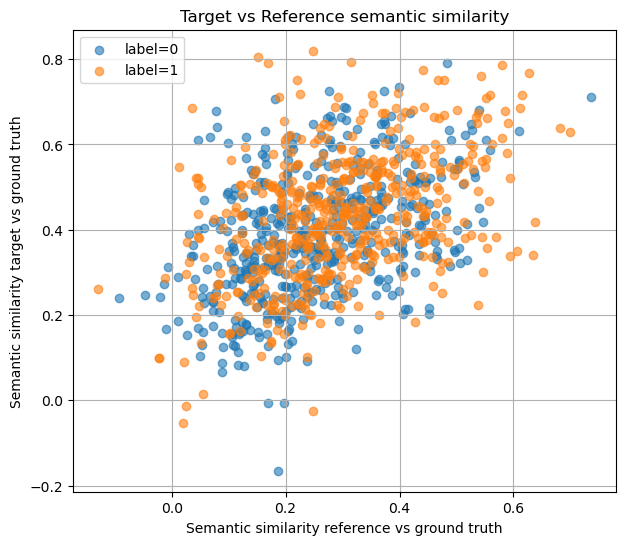

In [ ]:
plt.figure(figsize=(7, 6))

for label, group in df_cmp.groupby("label"):
    plt.scatter(
        group["semantic_similarity_reference"],
        group["semantic_similarity_target"],
        alpha=0.6,
        label=f"label={label}"
    )

plt.xlabel("Semantic similarity reference vs ground truth")
plt.ylabel("Semantic similarity target vs ground truth")
plt.title("Target vs Reference semantic similarity")
plt.legend()
plt.grid(True)
plt.show()

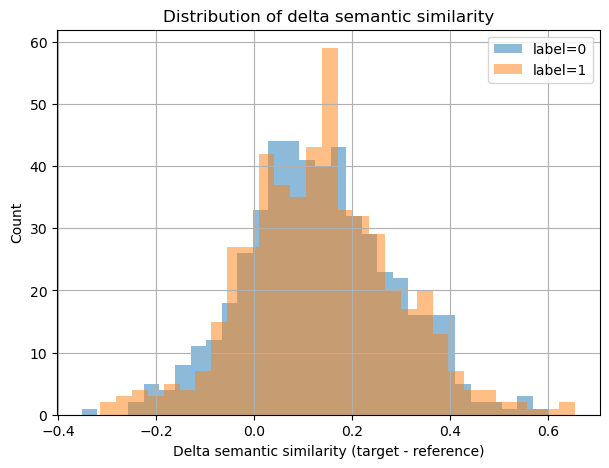

In [45]:
plt.figure(figsize=(7, 5))

for label, group in df_cmp.groupby("label"):
    plt.hist(
        group["delta_semantic_similarity"],
        bins=30,
        alpha=0.5,
        label=f"label={label}"
    )

plt.xlabel("Delta semantic similarity (target - reference)")
plt.ylabel("Count")
plt.title("Distribution of delta semantic similarity")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\isiva\AppData\Local\Temp\ipykernel_11536\3317190144.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["non-member", "member"])


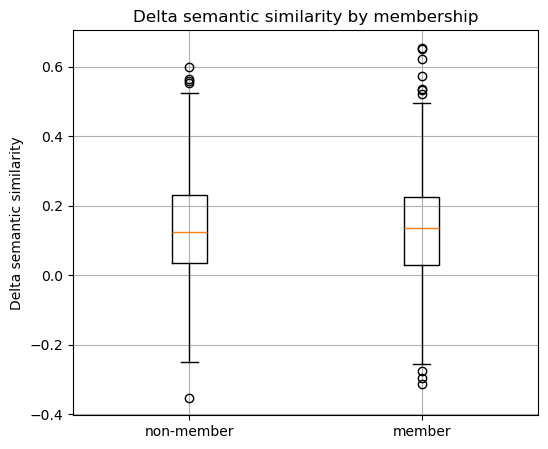

In [46]:
plt.figure(figsize=(6, 5))

data = [
    df_cmp[df_cmp["label"] == 0]["delta_semantic_similarity"],
    df_cmp[df_cmp["label"] == 1]["delta_semantic_similarity"],
]

plt.boxplot(data, labels=["non-member", "member"])
plt.ylabel("Delta semantic similarity")
plt.title("Delta semantic similarity by membership")
plt.grid(True)
plt.show()

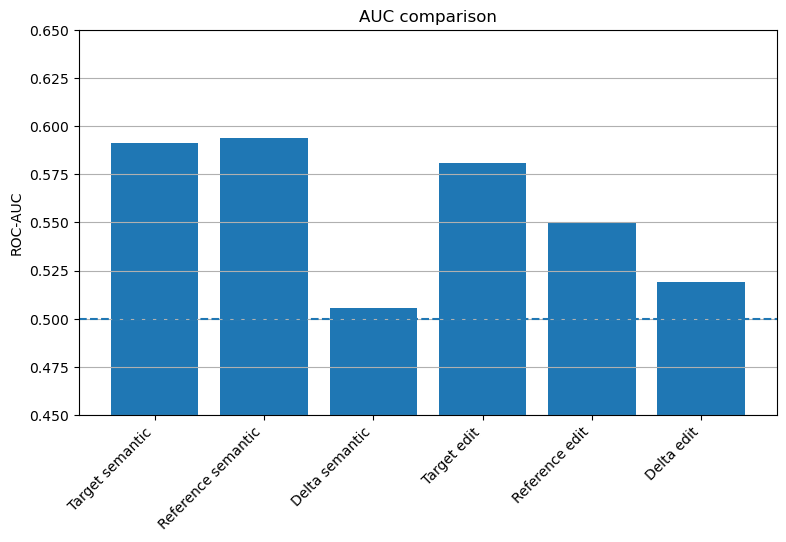

In [47]:
auc_values = {
    "Target semantic": roc_auc_score(df_cmp["label"], df_cmp["semantic_similarity_target"]),
    "Reference semantic": roc_auc_score(df_cmp["label"], df_cmp["semantic_similarity_reference"]),
    "Delta semantic": roc_auc_score(df_cmp["label"], df_cmp["delta_semantic_similarity"]),
    "Target edit": roc_auc_score(df_cmp["label"], df_cmp["edit_similarity_target"]),
    "Reference edit": roc_auc_score(df_cmp["label"], df_cmp["edit_similarity_reference"]),
    "Delta edit": roc_auc_score(df_cmp["label"], df_cmp["delta_edit_similarity"]),
}

plt.figure(figsize=(9, 5))
plt.bar(auc_values.keys(), auc_values.values())
plt.axhline(0.5, linestyle="--")
plt.ylabel("ROC-AUC")
plt.title("AUC comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.45, 0.65)
plt.grid(axis="y")
plt.show()